In [1]:
# Import basic libraries for data handling and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load MNIST dataset from Keras
from tensorflow.keras.datasets import mnist

# Build Neural Network model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

# Confusion matrix for evaluation
from sklearn.metrics import confusion_matrix

In [2]:
# Load MNIST dataset (handwritten digits 0-9)
# x = images, y = labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [3]:
# Check dataset shapes
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


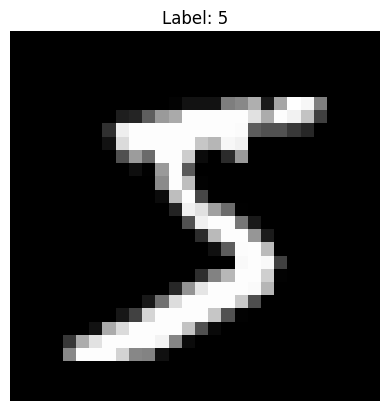

In [4]:
# Display one sample image from dataset
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [5]:
# Normalize pixel values (0-255 → 0-1)
# This helps model learn faster
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
# Convert labels into categorical format (0 → [1,0,0,...])
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [7]:
# Create Sequential Neural Network model
model = Sequential()

# Flatten 28x28 image into 1D vector
model.add(Flatten(input_shape=(28, 28)))

# Hidden layer with ReLU activation
model.add(Dense(128, activation='relu'))

# Dropout to reduce overfitting
model.add(Dropout(0.2))

# Output layer (10 classes → digits 0-9)
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Show model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Configure model training process
model.compile(
    optimizer='adam',  # optimizer
    loss='categorical_crossentropy',  # loss function for classification
    metrics=['accuracy']  # evaluation metric
)

In [10]:
# Train model on training data
history = model.fit(
    x_train,
    y_train,
    epochs=10,  # number of training rounds
    validation_split=0.2  # 20% for validation
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9038 - loss: 0.3282 - val_accuracy: 0.9532 - val_loss: 0.1626
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9520 - loss: 0.1602 - val_accuracy: 0.9647 - val_loss: 0.1173
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9638 - loss: 0.1211 - val_accuracy: 0.9691 - val_loss: 0.1041
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9699 - loss: 0.0973 - val_accuracy: 0.9736 - val_loss: 0.0908
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9748 - loss: 0.0809 - val_accuracy: 0.9737 - val_loss: 0.0881
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9776 - loss: 0.0713 - val_accuracy: 0.9753 - val_loss: 0.0850
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9804 - loss: 0.0611 - val_accuracy: 0.9743 - val_loss: 0.0870
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9819 - loss: 0.0569 - 

In [11]:
# Evaluate model on unseen test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9792 - loss: 0.0735
Test Loss: 0.07352543622255325
Test Accuracy: 0.979200005531311


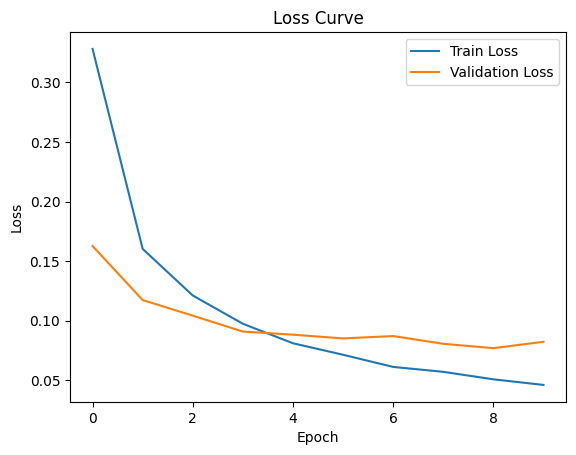

In [12]:
# Plot training vs validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

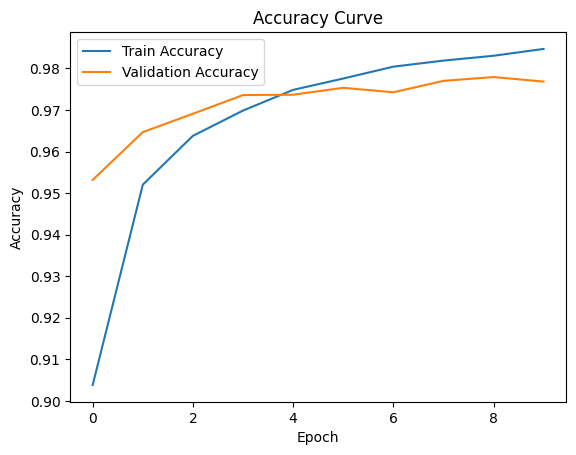

In [13]:
# Plot training vs validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [14]:
# Make predictions on test data
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


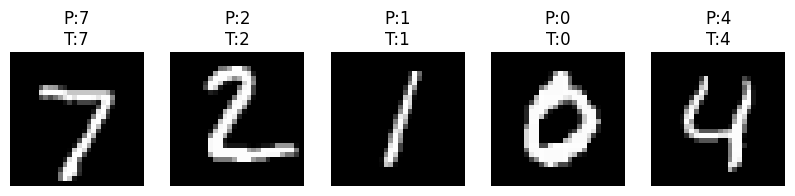

In [15]:
# Show sample predictions vs actual labels
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i], cmap='gray')

    pred = np.argmax(predictions[i])
    true = np.argmax(y_test[i])

    plt.title(f"P:{pred}\nT:{true}")
    plt.axis('off')

plt.show()

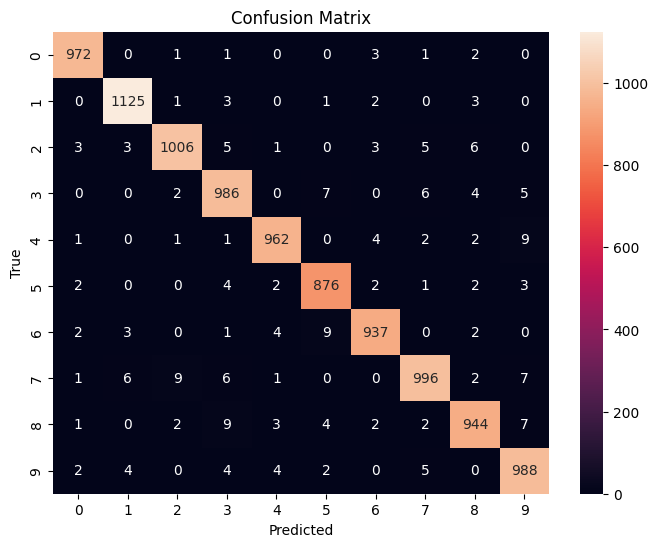

In [16]:
# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [17]:
# Build second model with different activation function (Tanh)
model2 = Sequential()

model2.add(Flatten(input_shape=(28, 28)))

model2.add(Dense(128, activation='tanh'))  # changed activation

model2.add(Dropout(0.2))

model2.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Compile second model
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Train second model
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8972 - loss: 0.3497 - val_accuracy: 0.9378 - val_loss: 0.2150
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9383 - loss: 0.2063 - val_accuracy: 0.9544 - val_loss: 0.1609
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9521 - loss: 0.1580 - val_accuracy: 0.9621 - val_loss: 0.1341
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9600 - loss: 0.1310 - val_accuracy: 0.9636 - val_loss: 0.1208
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9653 - loss: 0.1119 - val_accuracy: 0.9676 - val_loss: 0.1147
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9694 - loss: 0.0988 - val_accuracy: 0.9673 - val_loss: 0.1111
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9718 - loss: 0.0875 - val_accuracy: 0.9702 - val_loss: 0.1003
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9744 - loss: 0.0800 - 

In [20]:
# Evaluate second model
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Tanh Model Results")
print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9745 - loss: 0.0847
Tanh Model Results
Test Loss: 0.08473243564367294
Test Accuracy: 0.9745000004768372


In [21]:
# Compare both experiments

print("===== ReLU Model =====")
print("Accuracy:", test_accuracy)
print("Loss:", test_loss)

print("\n===== Tanh Model =====")
print("Accuracy:", test_accuracy2)
print("Loss:", test_loss2)

===== ReLU Model =====
Accuracy: 0.979200005531311
Loss: 0.07352543622255325

===== Tanh Model =====
Accuracy: 0.9745000004768372
Loss: 0.08473243564367294
